<a href="https://colab.research.google.com/github/Yeabebe/ZX-CENF/blob/feature%2Fzx-cenf-prototype/experiments/zx_optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup

In [61]:
# Install dependencies (Colab has networkx, matplotlib)
!pip install networkx matplotlib numpy -q

# Import required libraries

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

from dataclasses import dataclass
from copy import deepcopy
from typing import Dict, List, Tuple, Optional

print("ZX Pipeline Ready!")

ZX Pipeline Ready!


In [62]:
# ZX constants

Z_SPIDER = "Z"
X_SPIDER = "X"

NORMAL_EDGE = "normal"
HADAMARD_EDGE = "hadamard"


print("ZX Calculus Optimizer Setup Complete")

ZX Calculus Optimizer Setup Complete


ZX Graph Data Structures

In [63]:
@dataclass
class Spider:
    id: int
    color: str
    phase: float = 0.0

    def __repr__(self):
        return f"Spider(id={self.id}, color={self.color}, phase={self.phase})"


class ZXGraph:
    def __init__(self):
        self.graph = nx.Graph()
        self.spiders = {}
        self.next_id = 0


    def add_spider(self, color, phase=0.0):
        spider_id = self.next_id
        self.next_id += 1

        spider = Spider(
            id=spider_id,
            color=color,
            phase=phase
        )

        self.spiders[spider_id] = spider

        self.graph.add_node(
            spider_id,
            color=color,
            phase=phase
        )

        return spider_id


    def add_edge(self, spider1, spider2, edge_type="normal"):
        self.graph.add_edge(
            spider1,
            spider2,
            type=edge_type
        )


    def remove_spider(self, spider_id):
        if spider_id in self.spiders:
            del self.spiders[spider_id]

        if spider_id in self.graph:
            self.graph.remove_node(spider_id)


    def get_spider(self, spider_id):
        return self.spiders.get(spider_id)


    def neighbors(self, spider_id):
        return list(self.graph.neighbors(spider_id))


    def number_of_spiders(self):
        return self.graph.number_of_nodes()


    def number_of_edges(self):
        return self.graph.number_of_edges()


    def copy(self):
        return deepcopy(self)


    def summary(self):
        print("Spiders:", self.number_of_spiders())
        print("Edges:", self.number_of_edges())

        for node in self.graph.nodes:
            data = self.graph.nodes[node]
            print(
                node,
                "Color:",
                data["color"],
                "Phase:",
                data["phase"]
            )


print("ZXGraph class created successfully")

ZXGraph class created successfully


In [64]:
# Test ZXGraph creation

zx = ZXGraph()

s1 = zx.add_spider("Z", phase=0)
s2 = zx.add_spider("Z", phase=np.pi/4)
s3 = zx.add_spider("X", phase=np.pi)

zx.add_edge(s1, s2)
zx.add_edge(s2, s3)


zx.summary()

Spiders: 3
Edges: 2
0 Color: Z Phase: 0
1 Color: Z Phase: 0.7853981633974483
2 Color: X Phase: 3.141592653589793


Example Quantum Circuits

In [65]:
class QuantumCircuit:
    def __init__(self, qubits):
        self.qubits = qubits
        self.operations = []


    def add_gate(self, gate, qubit, target=None, phase=None):
        operation = {
            "gate": gate,
            "qubit": qubit,
            "target": target,
            "phase": phase
        }

        self.operations.append(operation)


    def display(self):
        for op in self.operations:
            print(op)



# Circuit 1: H - CNOT - T

circuit1 = QuantumCircuit(2)

circuit1.add_gate("H", 0)
circuit1.add_gate("CNOT", 0, target=1)
circuit1.add_gate("T", 0, phase=np.pi/4)



# Circuit 2: Clifford circuit

circuit2 = QuantumCircuit(1)

circuit2.add_gate("H", 0)
circuit2.add_gate("S", 0, phase=np.pi/2)
circuit2.add_gate("H", 0)



# Circuit 3: Non-Clifford circuit

circuit3 = QuantumCircuit(1)

circuit3.add_gate("T", 0, phase=np.pi/4)
circuit3.add_gate("H", 0)
circuit3.add_gate("Tdg", 0, phase=-np.pi/4)



print("Example circuits created")

Example circuits created


In [66]:
# Display circuits

print("Circuit 1")
circuit1.display()

print("\nCircuit 2")
circuit2.display()

print("\nCircuit 3")
circuit3.display()

Circuit 1
{'gate': 'H', 'qubit': 0, 'target': None, 'phase': None}
{'gate': 'CNOT', 'qubit': 0, 'target': 1, 'phase': None}
{'gate': 'T', 'qubit': 0, 'target': None, 'phase': 0.7853981633974483}

Circuit 2
{'gate': 'H', 'qubit': 0, 'target': None, 'phase': None}
{'gate': 'S', 'qubit': 0, 'target': None, 'phase': 1.5707963267948966}
{'gate': 'H', 'qubit': 0, 'target': None, 'phase': None}

Circuit 3
{'gate': 'T', 'qubit': 0, 'target': None, 'phase': 0.7853981633974483}
{'gate': 'H', 'qubit': 0, 'target': None, 'phase': None}
{'gate': 'Tdg', 'qubit': 0, 'target': None, 'phase': -0.7853981633974483}


Circuit to ZX Diagram Conversion

In [67]:
def circuit_to_zx(circuit):
    zx = ZXGraph()

    qubit_wires = {}

    for q in range(circuit.qubits):
        wire = zx.add_spider(
            color=Z_SPIDER,
            phase=0
        )
        qubit_wires[q] = wire


    for operation in circuit.operations:

        gate = operation["gate"]
        q = operation["qubit"]
        current = qubit_wires[q]


        if gate == "H":

            h_spider = zx.add_spider(
                color=X_SPIDER,
                phase=0
            )

            zx.add_edge(
                current,
                h_spider,
                HADAMARD_EDGE
            )

            qubit_wires[q] = h_spider



        elif gate == "T":

            t_spider = zx.add_spider(
                color=Z_SPIDER,
                phase=np.pi/4
            )

            zx.add_edge(
                current,
                t_spider
            )

            qubit_wires[q] = t_spider



        elif gate == "Tdg":

            t_spider = zx.add_spider(
                color=Z_SPIDER,
                phase=-np.pi/4
            )

            zx.add_edge(
                current,
                t_spider
            )

            qubit_wires[q] = t_spider



        elif gate == "S":

            s_spider = zx.add_spider(
                color=Z_SPIDER,
                phase=np.pi/2
            )

            zx.add_edge(
                current,
                s_spider
            )

            qubit_wires[q] = s_spider



        elif gate == "CNOT":

            control = q
            target = operation["target"]


            control_spider = zx.add_spider(
                color=Z_SPIDER,
                phase=0
            )

            target_spider = zx.add_spider(
                color=X_SPIDER,
                phase=0
            )


            zx.add_edge(
                qubit_wires[control],
                control_spider
            )

            zx.add_edge(
                qubit_wires[target],
                target_spider
            )


            zx.add_edge(
                control_spider,
                target_spider
            )


            qubit_wires[control] = control_spider
            qubit_wires[target] = target_spider


    return zx



print("Circuit to ZX conversion function created")

Circuit to ZX conversion function created


In [68]:
# Convert example circuits

zx1 = circuit_to_zx(circuit1)
zx2 = circuit_to_zx(circuit2)
zx3 = circuit_to_zx(circuit3)


print("Circuit 1 ZX Graph")
zx1.summary()


print("\nCircuit 2 ZX Graph")
zx2.summary()


print("\nCircuit 3 ZX Graph")
zx3.summary()

Circuit 1 ZX Graph
Spiders: 6
Edges: 5
0 Color: Z Phase: 0
1 Color: Z Phase: 0
2 Color: X Phase: 0
3 Color: Z Phase: 0
4 Color: X Phase: 0
5 Color: Z Phase: 0.7853981633974483

Circuit 2 ZX Graph
Spiders: 4
Edges: 3
0 Color: Z Phase: 0
1 Color: X Phase: 0
2 Color: Z Phase: 1.5707963267948966
3 Color: X Phase: 0

Circuit 3 ZX Graph
Spiders: 4
Edges: 3
0 Color: Z Phase: 0
1 Color: Z Phase: 0.7853981633974483
2 Color: X Phase: 0
3 Color: Z Phase: -0.7853981633974483


ZX Diagram Visualization

In [69]:
def draw_zx_graph(zx_graph, title="ZX Diagram"):

    G = zx_graph.graph

    plt.figure(figsize=(8, 5))

    pos = nx.spring_layout(
        G,
        seed=42
    )


    node_colors = []

    for node in G.nodes:

        color = G.nodes[node]["color"]

        if color == Z_SPIDER:
            node_colors.append("green")

        elif color == X_SPIDER:
            node_colors.append("red")

        else:
            node_colors.append("gray")


    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=node_colors,
        node_size=1200,
        font_size=10
    )


    edge_labels = {}

    for u, v, data in G.edges(data=True):

        edge_labels[(u, v)] = data.get(
            "type",
            "normal"
        )


    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels
    )


    plt.title(title)
    plt.show()



print("Visualization function created")

Visualization function created


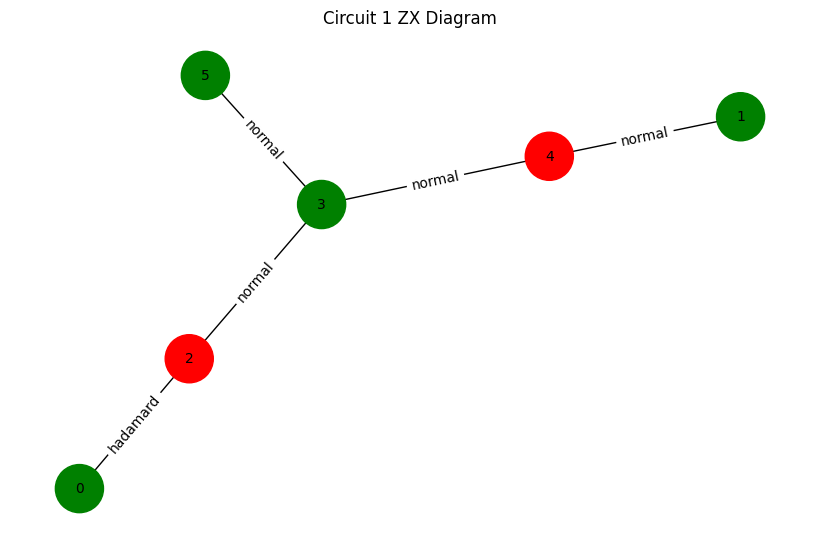

In [70]:
draw_zx_graph(
    zx1,
    "Circuit 1 ZX Diagram"
)

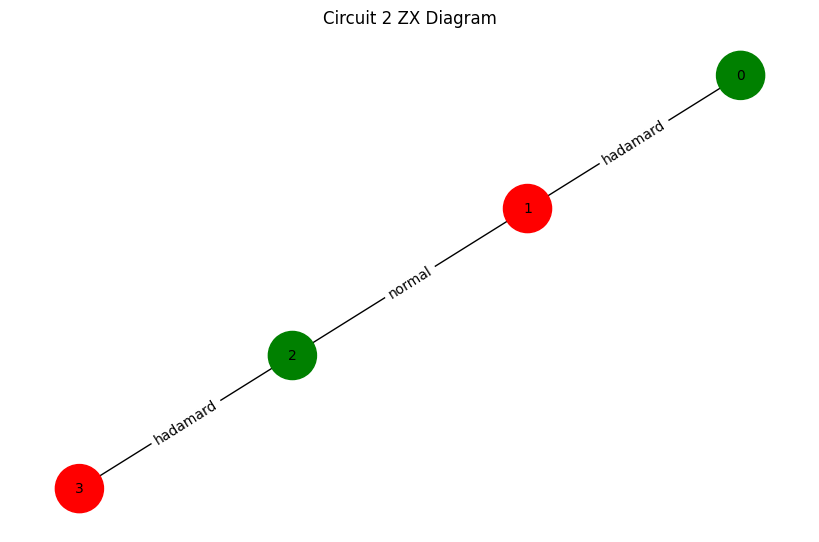

In [71]:
draw_zx_graph(
    zx2,
    "Circuit 2 ZX Diagram"
)

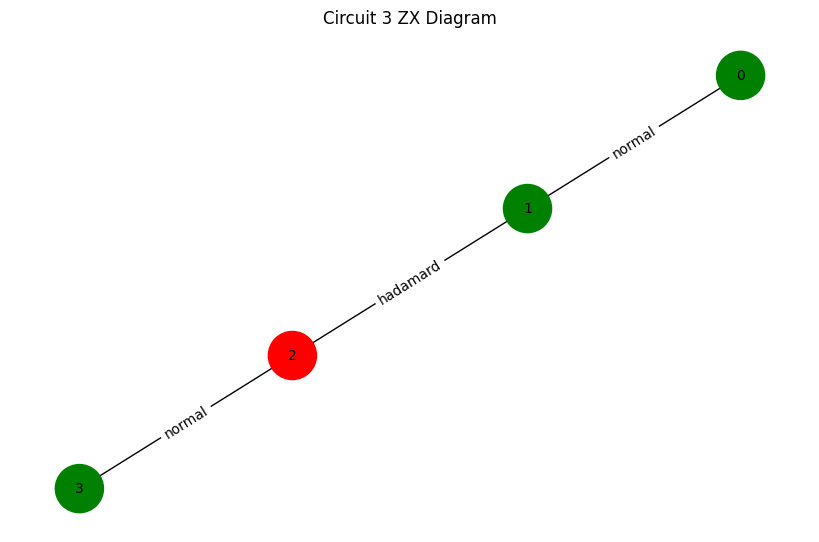

In [72]:
draw_zx_graph(
    zx3,
    "Circuit 3 ZX Diagram"
)

Spider Fusion Rewrite Rule

In [73]:
def find_spider_fusions(zx_graph):

    fusion_pairs = []

    G = zx_graph.graph


    for u, v, data in G.edges(data=True):

        color_u = G.nodes[u]["color"]
        color_v = G.nodes[v]["color"]

        edge_type = data.get("type", NORMAL_EDGE)

        # Spider fusion is allowed ONLY across normal edges
        if (
            color_u == color_v
            and edge_type == NORMAL_EDGE
        ):

            fusion_pairs.append((u, v))

    return fusion_pairs



print("Spider fusion detection created")

Spider fusion detection created


In [74]:
def apply_spider_fusion(zx_graph, pair):

    u, v = pair

    G = zx_graph.graph


    if u not in G.nodes or v not in G.nodes:
        return False


    color_u = G.nodes[u]["color"]
    color_v = G.nodes[v]["color"]

    edge_type = G[u][v].get("type", NORMAL_EDGE)

    if color_u != color_v:
        return False

    # Never fuse across Hadamard edges
    if edge_type != NORMAL_EDGE:
        return False


    phase_u = G.nodes[u]["phase"]
    phase_v = G.nodes[v]["phase"]


    new_phase = phase_u + phase_v


    neighbors_v = list(
        G.neighbors(v)
    )


    for n in neighbors_v:

        if n != u:

            edge_data = G.get_edge_data(
                v,
                n
            )

            G.add_edge(
                u,
                n,
                **edge_data
            )


    G.nodes[u]["phase"] = new_phase


    zx_graph.remove_spider(v)


    return True



print("Spider fusion rewrite created")

Spider fusion rewrite created


In [75]:
# Test spider fusion

test_zx = ZXGraph()

a = test_zx.add_spider(
    Z_SPIDER,
    phase=np.pi/4
)

b = test_zx.add_spider(
    Z_SPIDER,
    phase=np.pi/2
)

c = test_zx.add_spider(
    X_SPIDER,
    phase=0
)


test_zx.add_edge(a,b)
test_zx.add_edge(b,c)


print("Before Fusion")
test_zx.summary()


fusion = find_spider_fusions(test_zx)

print("\nFusion candidates:")
print(fusion)


apply_spider_fusion(
    test_zx,
    fusion[0]
)


print("\nAfter Fusion")
test_zx.summary()

Before Fusion
Spiders: 3
Edges: 2
0 Color: Z Phase: 0.7853981633974483
1 Color: Z Phase: 1.5707963267948966
2 Color: X Phase: 0

Fusion candidates:
[(0, 1)]

After Fusion
Spiders: 2
Edges: 1
0 Color: Z Phase: 2.356194490192345
2 Color: X Phase: 0


Identity Removal Rewrite Rule

In [111]:
def find_identity_nodes(zx_graph):

    identity_nodes = []

    G = zx_graph.graph


    for node in G.nodes:

        degree = G.degree(node)

        phase = G.nodes[node]["phase"]

        color = G.nodes[node]["color"]


        # Check connected edges
        edges = []

        for neighbor in G.neighbors(node):
            edge_type = G[node][neighbor].get(
                "type",
                NORMAL_EDGE
            )

            edges.append(edge_type)


        # Identity removal:
        # - spider has phase 0
        # - degree exactly 2
        # - both edges are normal
        # - no boundary handling yet

        if (
            degree == 2
            and np.isclose(phase, 0)
            and all(edge == NORMAL_EDGE for edge in edges)
        ):

            identity_nodes.append(node)


    return identity_nodes

In [112]:
def apply_identity_removal(zx_graph, node):

    G = zx_graph.graph


    if node not in G.nodes:
        return False


    neighbors = list(
        G.neighbors(node)
    )


    if len(neighbors) != 2:
        return False


    n1 = neighbors[0]
    n2 = neighbors[1]


    edge1 = G.get_edge_data(
        node,
        n1
    )

    edge2 = G.get_edge_data(
        node,
        n2
    )


    # Preserve edge type only for normal identity removal

    if (
        G[node][n1].get("type", NORMAL_EDGE) == NORMAL_EDGE
        and
        G[node][n2].get("type", NORMAL_EDGE) == NORMAL_EDGE
    ):

        G.add_edge(
            n1,
            n2,
            type=NORMAL_EDGE
        )

    else:
        return False

    zx_graph.remove_spider(node)


    return True



print("Identity removal rewrite created")

Identity removal rewrite created


In [113]:
# Test identity removal

identity_test = ZXGraph()


s1 = identity_test.add_spider(
    Z_SPIDER,
    phase=0
)

s2 = identity_test.add_spider(
    Z_SPIDER,
    phase=0
)

s3 = identity_test.add_spider(
    X_SPIDER,
    phase=np.pi
)


identity_test.add_edge(s1,s2)
identity_test.add_edge(s2,s3)


print("Before Identity Removal")

identity_test.summary()


identity_nodes = find_identity_nodes(
    identity_test
)


print("\nIdentity nodes:")
print(identity_nodes)


for node in identity_nodes:
    apply_identity_removal(
        identity_test,
        node
    )


print("\nAfter Identity Removal")

identity_test.summary()

Before Identity Removal
Spiders: 3
Edges: 2
0 Color: Z Phase: 0
1 Color: Z Phase: 0
2 Color: X Phase: 3.141592653589793

Identity nodes:
[1]

After Identity Removal
Spiders: 2
Edges: 1
0 Color: Z Phase: 0
2 Color: X Phase: 3.141592653589793


Rewrite Heuristic

In [114]:
def choose_rewrite(zx_graph):

    fusion_candidates = find_spider_fusions(
        zx_graph
    )


    if len(fusion_candidates) > 0:

        return {
            "rule": "fusion",
            "data": fusion_candidates[0]
        }


    identity_candidates = find_identity_nodes(
        zx_graph
    )


    if len(identity_candidates) > 0:

        return {
            "rule": "identity",
            "data": identity_candidates[0]
        }


    return None



print("Greedy rewrite heuristic created")

Greedy rewrite heuristic created


ZX Optimization Loop

In [115]:
def optimize_zx(zx_graph, max_iterations=100):

    iteration = 0


    while iteration < max_iterations:


        rewrite = choose_rewrite(
            zx_graph
        )


        if rewrite is None:
            break



        if rewrite["rule"] == "fusion":

            apply_spider_fusion(
                zx_graph,
                rewrite["data"]
            )


        elif rewrite["rule"] == "identity":

            apply_identity_removal(
                zx_graph,
                rewrite["data"]
            )


        iteration += 1



    return zx_graph



print("ZX optimizer created")

ZX optimizer created


In [116]:
# Test optimization on Circuit 1

# Recreate fresh ZX graph
zx1 = circuit_to_zx(circuit1)

# Save original graph before optimization
before = deepcopy(zx1)


print("Before Optimization")
before.summary()


# Run optimizer
optimized_zx1 = optimize_zx(
    zx1
)


print("\nAfter Optimization")
optimized_zx1.summary()

Before Optimization
Spiders: 6
Edges: 5
0 Color: Z Phase: 0
1 Color: Z Phase: 0
2 Color: X Phase: 0
3 Color: Z Phase: 0
4 Color: X Phase: 0
5 Color: Z Phase: 0.7853981633974483

After Optimization
Spiders: 3
Edges: 2
0 Color: Z Phase: 0
1 Color: Z Phase: 0.7853981633974483
2 Color: X Phase: 0


Optimization Statistics

In [117]:
def optimization_report(before, after):

    old_nodes = before.number_of_spiders()
    new_nodes = after.number_of_spiders()


    old_edges = before.number_of_edges()
    new_edges = after.number_of_edges()


    if old_nodes > 0:
        node_reduction = (
            (old_nodes - new_nodes)
            / old_nodes
            * 100
        )
    else:
        node_reduction = 0


    if old_edges > 0:
        edge_reduction = (
            (old_edges - new_edges)
            / old_edges
            * 100
        )
    else:
        edge_reduction = 0


    print("Optimization Report")
    print("-------------------")

    print(
        f"Nodes: {old_nodes} -> {new_nodes}"
    )

    print(
        f"Edges: {old_edges} -> {new_edges}"
    )

    print(
        f"Node Reduction: {node_reduction:.2f}%"
    )

    print(
        f"Edge Reduction: {edge_reduction:.2f}%"
    )



print("Report function created")

Report function created


In [118]:
# Generate optimization report

optimization_report(
    before,
    optimized_zx1
)

Optimization Report
-------------------
Nodes: 6 -> 3
Edges: 5 -> 2
Node Reduction: 50.00%
Edge Reduction: 60.00%


Final ZX Optimization Examples



Circuit 1
----------

Before:
Spiders: 6
Edges: 5
0 Color: Z Phase: 0
1 Color: Z Phase: 0
2 Color: X Phase: 0
3 Color: Z Phase: 0
4 Color: X Phase: 0
5 Color: Z Phase: 0.7853981633974483

After:
Spiders: 3
Edges: 2
0 Color: Z Phase: 0
1 Color: Z Phase: 0.7853981633974483
2 Color: X Phase: 0
Optimization Report
-------------------
Nodes: 6 -> 3
Edges: 5 -> 2
Node Reduction: 50.00%
Edge Reduction: 60.00%


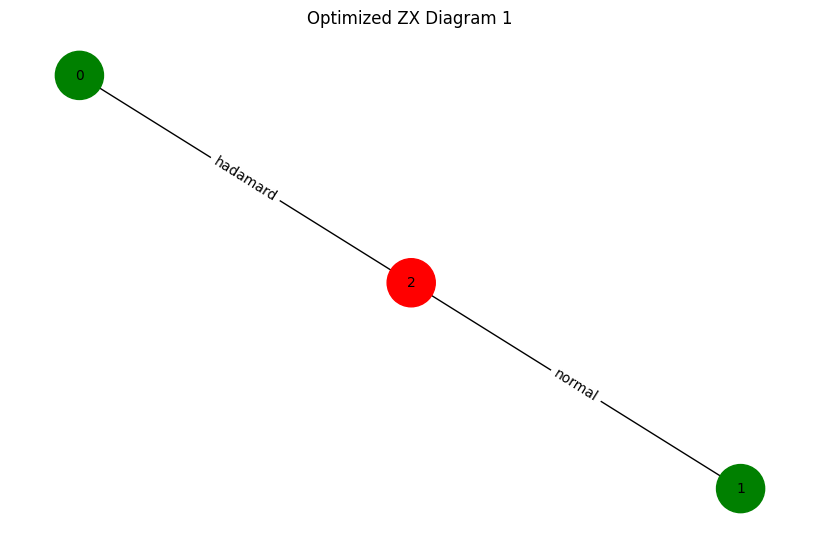



Circuit 2
----------

Before:
Spiders: 4
Edges: 3
0 Color: Z Phase: 0
1 Color: X Phase: 0
2 Color: Z Phase: 1.5707963267948966
3 Color: X Phase: 0

After:
Spiders: 4
Edges: 3
0 Color: Z Phase: 0
1 Color: X Phase: 0
2 Color: Z Phase: 1.5707963267948966
3 Color: X Phase: 0
Optimization Report
-------------------
Nodes: 4 -> 4
Edges: 3 -> 3
Node Reduction: 0.00%
Edge Reduction: 0.00%


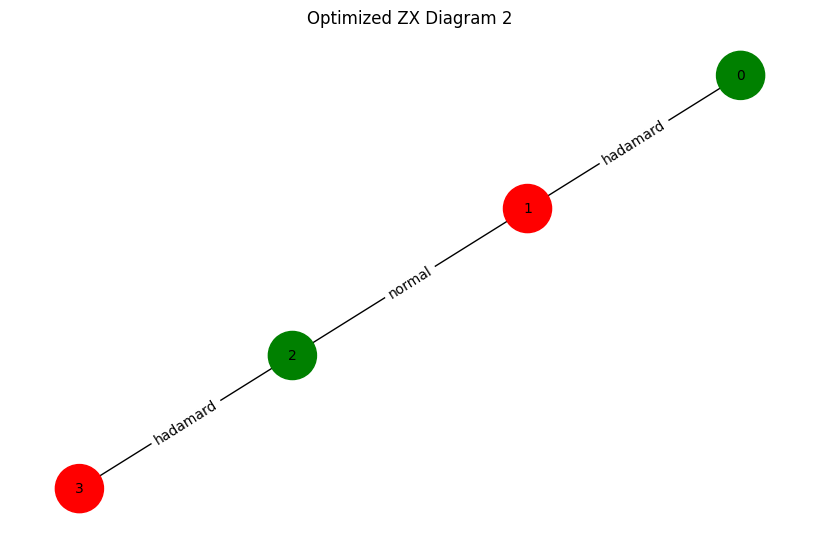



Circuit 3
----------

Before:
Spiders: 4
Edges: 3
0 Color: Z Phase: 0
1 Color: Z Phase: 0.7853981633974483
2 Color: X Phase: 0
3 Color: Z Phase: -0.7853981633974483

After:
Spiders: 3
Edges: 2
0 Color: Z Phase: 0.7853981633974483
2 Color: X Phase: 0
3 Color: Z Phase: -0.7853981633974483
Optimization Report
-------------------
Nodes: 4 -> 3
Edges: 3 -> 2
Node Reduction: 25.00%
Edge Reduction: 33.33%


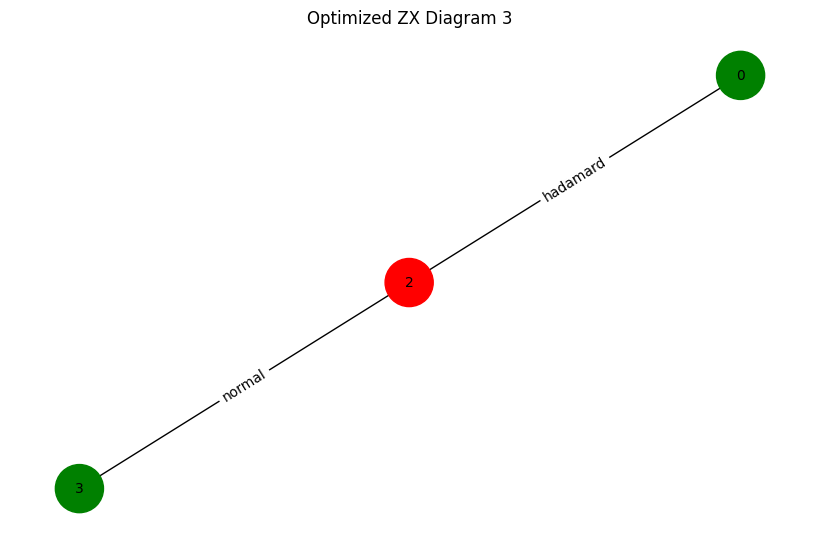

In [119]:
circuits = [
    circuit1,
    circuit2,
    circuit3
]


for i, circuit in enumerate(circuits):

    print("\n")
    print(f"Circuit {i+1}")
    print("-"*10)


    zx = circuit_to_zx(
        circuit
    )


    original = deepcopy(zx)


    print("\nBefore:")
    original.summary()


    optimized = optimize_zx(
        zx
    )


    print("\nAfter:")
    optimized.summary()


    optimization_report(
        original,
        optimized
    )


    draw_zx_graph(
        optimized,
        f"Optimized ZX Diagram {i+1}"
    )